# Spectrograms, Mel Scale & Audio Features

Dans ce notebook, nous allons transformer une waveform brute en représentations plus utiles pour les modèles de Speech AI.

Nous allons progressivement construire :

- une STFT ;
- un spectrogramme ;
- un spectrogramme en décibels ;
- un Mel-spectrogramme ;
- un log-Mel spectrogramme.

L’objectif est de comprendre comment passer d’un signal audio dans le temps à une représentation contenant le temps, les fréquences et l’intensité.

## 1. Importation des bibliothèques

Nous importons les outils nécessaires pour :

- charger et manipuler l’audio ;
- calculer la STFT ;
- créer les spectrogrammes ;
- construire les représentations Mel ;
- afficher les résultats.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import librosa.display

from pathlib import Path

## 2. Définition du chemin audio

Nous définissons le chemin vers le fichier WAV utilisé dans ce notebook.

Le notebook est stocké dans le dossier `notebooks/`, mais Jupyter est lancé depuis la racine du projet. Le fichier audio est donc accessible depuis :

```text
audio_samples/voice_excerpt.wav

In [2]:
audio_path = Path("audio_samples/voice_excerpt.wav")

print("Chemin absolu :", audio_path.resolve())
print("Le fichier existe :", audio_path.exists())

Chemin absolu : /Users/ziyadamine/Documents/weather-audio-learning/audio_samples/voice_excerpt.wav
Le fichier existe : True


## 3. Chargement du fichier audio

Nous chargeons le fichier WAV avec `soundfile`.

La fonction retourne :

- `audio` : le tableau contenant les échantillons ;
- `sample_rate` : le nombre d’échantillons par seconde.

Nous vérifions aussi la forme du tableau et la durée du signal.

In [3]:
audio, sample_rate = sf.read(audio_path)

duration = len(audio) / sample_rate

print("Sample rate :", sample_rate, "Hz")
print("Shape :", audio.shape)
print(f"Durée : {duration:.2f} secondes")

Sample rate : 44100 Hz
Shape : (36823040,)
Durée : 834.99 secondes


## 4. Sélection d’un extrait court

Le fichier complet dure environ 835 secondes. Pour faciliter les calculs et les visualisations, nous sélectionnons un extrait de 10 secondes.

Nous commençons à la 20e seconde afin d’éviter une éventuelle introduction ou un silence au début du fichier.

Toutes les prochaines transformations seront effectuées sur cet extrait.

In [4]:
start_time = 20
excerpt_duration = 10

start_sample = int(start_time * sample_rate)
end_sample = int((start_time + excerpt_duration) * sample_rate)

audio_excerpt = audio[start_sample:end_sample]

print("Shape de l'extrait :", audio_excerpt.shape)
print(
    "Durée de l'extrait :",
    len(audio_excerpt) / sample_rate,
    "secondes"
)

Shape de l'extrait : (441000,)
Durée de l'extrait : 10.0 secondes


## 5. Vérification du nombre de canaux

Avant de calculer les features audio, nous vérifions si l’extrait est mono ou stéréo.

De nombreux modèles de Speech AI attendent un signal mono.

Si le signal possède plusieurs canaux, nous calculons leur moyenne pour obtenir un seul canal.

In [5]:
if audio_excerpt.ndim == 2:
    audio_excerpt = audio_excerpt.mean(axis=1)
    print("Extrait converti en mono.")
else:
    print("L'extrait est déjà mono.")

print("Shape finale :", audio_excerpt.shape)

L'extrait est déjà mono.
Shape finale : (441000,)


## 6. Rééchantillonnage à 16 kHz

L’extrait est actuellement à 44 100 Hz.

Pour les exercices de Speech AI, nous le convertissons à 16 000 Hz, une fréquence couramment utilisée pour la parole.

Le rééchantillonnage réduit le nombre d’échantillons, mais conserve la même durée.

In [6]:
target_sample_rate = 16000

audio_16k = librosa.resample(
    audio_excerpt,
    orig_sr=sample_rate,
    target_sr=target_sample_rate
)

print("Sample rate original :", sample_rate, "Hz")
print("Sample rate cible :", target_sample_rate, "Hz")
print("Échantillons avant :", len(audio_excerpt))
print("Échantillons après :", len(audio_16k))
print(
    "Durée après :",
    len(audio_16k) / target_sample_rate,
    "secondes"
)

Sample rate original : 44100 Hz
Sample rate cible : 16000 Hz
Échantillons avant : 441000
Échantillons après : 160000
Durée après : 10.0 secondes


## 7. Paramètres de la STFT

Pour analyser la parole, nous découpons le signal en petites fenêtres.

Nous utilisons ici :

- une fenêtre de 25 millisecondes ;
- un déplacement de 10 millisecondes entre deux fenêtres ;
- un sample rate de 16 kHz.

À 16 kHz :

- 25 ms correspondent à 400 échantillons ;
- 10 ms correspondent à 160 échantillons.

Les fenêtres se chevauchent afin de conserver les changements du signal entre deux frames.

In [7]:
window_duration = 0.025
hop_duration = 0.010

window_length = int(window_duration * target_sample_rate)
hop_length = int(hop_duration * target_sample_rate)

print("Taille de la fenêtre :", window_length, "échantillons")
print("Taille du hop :", hop_length, "échantillons")

Taille de la fenêtre : 400 échantillons
Taille du hop : 160 échantillons


## 8. Calcul de la STFT

La STFT découpe le signal en petites fenêtres qui se chevauchent, applique une fenêtre de Hann à chaque morceau, puis calcule une FFT sur chaque frame.

Le résultat contient des nombres complexes. Chaque valeur contient :

- une magnitude, qui représente l’intensité de la fréquence ;
- une phase, qui représente son décalage.

Pour construire le spectrogramme, nous utiliserons principalement la magnitude.

In [8]:
stft = librosa.stft(
    audio_16k,
    n_fft=window_length,
    hop_length=hop_length,
    win_length=window_length,
    window="hann"
)

print("Shape de la STFT :", stft.shape)
print("Type des valeurs :", stft.dtype)

Shape de la STFT : (201, 1001)
Type des valeurs : complex128


201 = les bandes de fréquences ;
1001 = les positions temporelles ;
complex128 = chaque valeur contient amplitude + phase.

## 9. Extraction de la magnitude

La STFT retourne des nombres complexes.

Pour construire un spectrogramme classique, nous utilisons leur valeur absolue, appelée magnitude.

La magnitude indique l’intensité de chaque fréquence à chaque instant.

La phase existe toujours dans la STFT, mais elle n’est pas utilisée ici pour la visualisation du spectrogramme.

In [9]:
magnitude = np.abs(stft)

print("Shape de la magnitude :", magnitude.shape)
print("Valeur minimale :", magnitude.min())
print("Valeur maximale :", magnitude.max())

Shape de la magnitude : (201, 1001)
Valeur minimale : 1.7679021874911216e-10
Valeur maximale : 28.79962173281232


## 10. Conversion en décibels

Les magnitudes brutes peuvent avoir des écarts très importants.

Les fréquences fortes risquent donc de masquer les fréquences plus faibles dans le graphique.

Nous convertissons la magnitude en décibels afin de compresser cette dynamique et d’obtenir un spectrogramme plus lisible.

In [10]:
magnitude_db = librosa.amplitude_to_db(
    magnitude,
    ref=np.max
)

print("Shape :", magnitude_db.shape)
print("Valeur minimale :", magnitude_db.min())
print("Valeur maximale :", magnitude_db.max())

Shape : (201, 1001)
Valeur minimale : -80.0
Valeur maximale : 0.0


## 11. Visualisation du spectrogramme

Le spectrogramme représente l’évolution des fréquences au cours du temps.

- l’axe horizontal représente le temps ;
- l’axe vertical représente les fréquences en hertz ;
- la couleur représente l’intensité en décibels.

Les zones les plus claires correspondent aux fréquences les plus énergétiques.

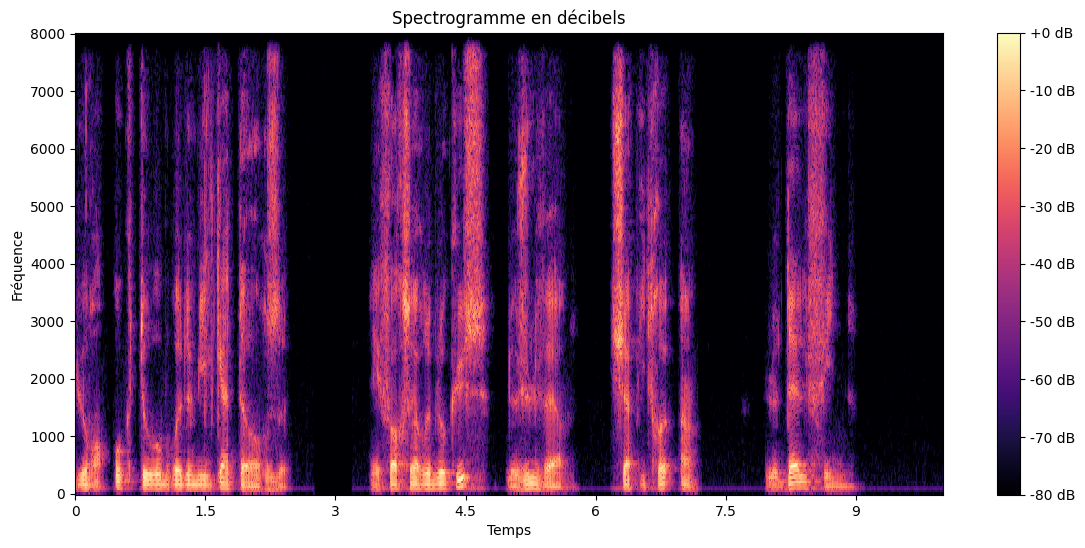

In [11]:
plt.figure(figsize=(14, 6))

librosa.display.specshow(
    magnitude_db,
    sr=target_sample_rate,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogramme en décibels")
plt.xlabel("Temps")
plt.ylabel("Fréquence")
plt.show()

## 12. Calcul du Mel-spectrogramme

Le spectrogramme classique utilise une échelle de fréquences linéaire.

Cependant, l’oreille humaine ne perçoit pas toutes les fréquences avec la même précision. Nous distinguons mieux les différences dans les basses fréquences que dans les hautes.

Le Mel-spectrogramme regroupe donc les fréquences selon une échelle plus proche de la perception humaine.

Nous utilisons ici 80 bandes Mel, une configuration fréquente pour les systèmes de reconnaissance vocale.

In [12]:
n_mels = 80

mel_spectrogram = librosa.feature.melspectrogram(
    y=audio_16k,
    sr=target_sample_rate,
    n_fft=window_length,
    hop_length=hop_length,
    win_length=window_length,
    window="hann",
    n_mels=n_mels,
    power=2.0
)

print("Shape du Mel-spectrogramme :", mel_spectrogram.shape)
print("Valeur minimale :", mel_spectrogram.min())
print("Valeur maximale :", mel_spectrogram.max())

Shape du Mel-spectrogramme : (80, 1001)
Valeur minimale : 8.719245272532801e-13
Valeur maximale : 20.12318574097663


80 lignes = les 80 bandes Mel ;
1001 colonnes = les positions temporelles ;
les valeurs représentent ici une énergie, car power=2.0.

## 13. Conversion en log-Mel spectrogramme

Le Mel-spectrogramme contient encore des valeurs avec une grande différence d’échelle.

Nous le convertissons donc en décibels afin de compresser la dynamique.

Le résultat est un log-Mel spectrogramme, une représentation très utilisée dans les modèles de Speech AI.

In [13]:
log_mel_spectrogram = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

print("Shape du log-Mel :", log_mel_spectrogram.shape)
print("Valeur minimale :", log_mel_spectrogram.min())
print("Valeur maximale :", log_mel_spectrogram.max())

Shape du log-Mel : (80, 1001)
Valeur minimale : -80.0
Valeur maximale : 0.0


## 14. Visualisation du log-Mel spectrogramme

Le log-Mel spectrogramme représente l’énergie du signal dans 80 bandes de fréquences adaptées à la perception humaine.

- l’axe horizontal représente le temps ;
- l’axe vertical représente les fréquences sur l’échelle Mel ;
- la couleur représente l’énergie en décibels.

Par rapport au spectrogramme classique, cette représentation accorde davantage de précision aux fréquences importantes pour la parole.

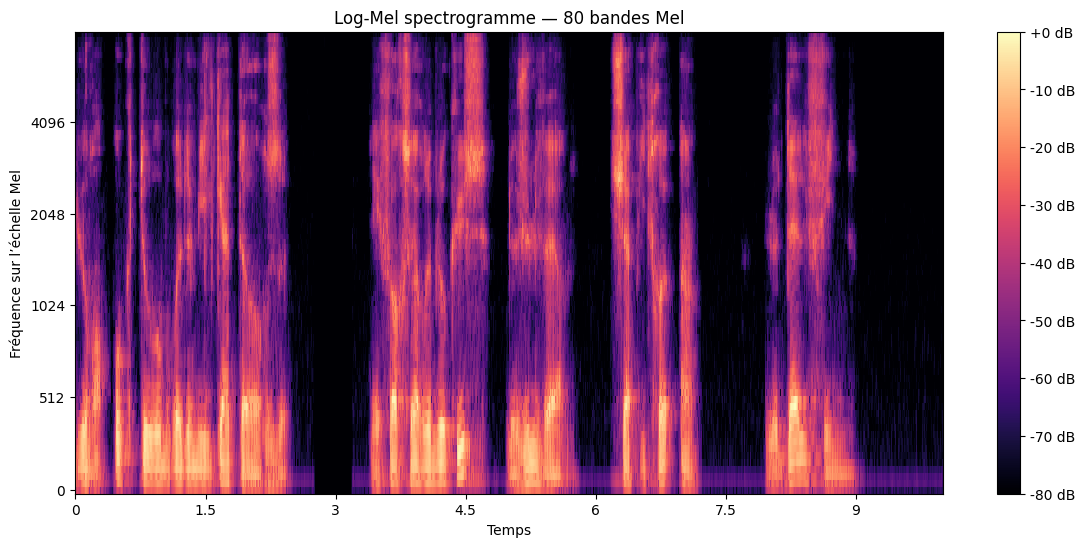

In [14]:
plt.figure(figsize=(14, 6))

librosa.display.specshow(
    log_mel_spectrogram,
    sr=target_sample_rate,
    hop_length=hop_length,
    x_axis="time",
    y_axis="mel",
    fmax=target_sample_rate / 2
)

plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel spectrogramme — 80 bandes Mel")
plt.xlabel("Temps")
plt.ylabel("Fréquence sur l’échelle Mel")
plt.show()

## 15. Comparaison entre spectrogramme classique et log-Mel

Le spectrogramme classique conserve les fréquences sur une échelle linéaire en hertz.

Le log-Mel spectrogramme regroupe les fréquences selon une échelle plus proche de la perception humaine.

Le spectrogramme classique est utile pour inspecter précisément le contenu fréquentiel du signal.

Le log-Mel est plus compact et souvent mieux adapté comme entrée pour les modèles de Speech AI.

In [15]:
print("Spectrogramme classique :", magnitude_db.shape)
print("Log-Mel spectrogramme :", log_mel_spectrogram.shape)

print(
    "Réduction du nombre de bandes :",
    magnitude_db.shape[0],
    "→",
    log_mel_spectrogram.shape[0]
)

Spectrogramme classique : (201, 1001)
Log-Mel spectrogramme : (80, 1001)
Réduction du nombre de bandes : 201 → 80


# Conclusion

Dans ce notebook, nous avons transformé une waveform brute en représentations plus adaptées aux modèles de Speech AI.

Nous avons réalisé les étapes suivantes :

- chargement d’un fichier audio ;
- sélection d’un extrait court ;
- vérification mono/stéréo ;
- rééchantillonnage à 16 kHz ;
- définition de fenêtres de 25 ms et d’un hop de 10 ms ;
- calcul de la STFT ;
- extraction de la magnitude ;
- conversion en décibels ;
- visualisation du spectrogramme ;
- calcul d’un Mel-spectrogramme avec 80 bandes ;
- conversion en log-Mel ;
- comparaison entre spectrogramme classique et log-Mel.

Le spectrogramme classique conserve 201 bandes fréquentielles, tandis que le log-Mel les réduit à 80 bandes adaptées à la perception humaine, sans modifier les 1001 positions temporelles.

Le pipeline principal est :

```text
Waveform
→ STFT
→ magnitude
→ spectrogramme en décibels
→ filtres Mel
→ Mel-spectrogramme
→ log-Mel spectrogramme